In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import pandas as pd
import numpy as np
#import seaborn as sns
import matplotlib.pyplot as plt

from itertools import chain

from monte_carlo_return import (
    generate_bet_return,
    compute_objective_via_simulation,
    minimize_simulation,
    INDEX_TO_SCENARIO
)
from analytical_return import (
    expectation,
    second_moment,
    variance,
    compute_objective_via_analytical,
    softmax,
)
from data import (
    load_metadata_artefacts,
    load_odds,
    join_metadata,
    build_empty_dataframe,
    apply_final_treatment,
)
from GameProbs import GameProbs
from dependencies.utils import get_scenarios
from filter import filter_by_linear_combination
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [43]:
metadata, gameid_to_outcome = load_metadata_artefacts("data/metadata-with-date-new.parquet")
odds = load_odds("data/odds-new.parquet")
odds = join_metadata(odds, metadata)
print(metadata.shape)
print(odds.shape)

(17311, 9)
(2113785, 10)


In [44]:
odds.sample(30)

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime
1226642,5255103,LeoVegas Sport,exact,2 : 3,o,81.00,0.012346,Atlético Mineiro,Ceará,2021-10-09
900495,4396282,Megapari Sport,h2h,,h,1.77,0.564972,Fluminense,Fortaleza,2021-02-26
28902,2762896,1xBet,exact,4 : 0,o,56.00,0.017857,Fluminense,Botafogo,2019-05-11
1138275,5255267,LeoVegas Sport,over/under,3.5,over,4.60,0.217391,Santos,Internacional,2021-08-22
1389743,5254884,Megapari Sport,exact,6 : 3,o,201.00,0.004975,Cuiabá,Palmeiras,2021-12-01
92356,2823111,22Bet,exact,4 : 2,o,101.00,0.009901,Corinthians,CSA,2019-07-14
833282,4396232,Betway,exact,5 : 2,o,81.00,0.012346,Palmeiras,Botafogo,2021-02-02
426695,4698257,Bethard,both_score,,no,1.65,0.606061,Fluminense,Internacional,2020-08-16
1841915,5924906,Betway,exact,3 : 3,o,67.00,0.014925,Atlético Mineiro,Fluminense,2022-10-01
1433956,5925496,Megapari Sport,exact,1 : 2,o,14.00,0.071429,Coritiba,Goiás,2022-04-10


In [45]:
print(odds[odds.Market=="h2h"].Bet.value_counts())
replacements = {
    'h': 'home',
    'a': 'away',
    'r': 'draw',
}
odds["Bet"] = odds["Bet"].replace(replacements)
print(odds[odds.Market=="h2h"].Bet.value_counts())

Bet
h       33087
r       33087
a       33087
home    22350
draw    22350
away    22350
Name: count, dtype: int64
Bet
home    55437
draw    55437
away    55437
Name: count, dtype: int64


In [46]:
odds = odds[(odds.Market=="h2h")]
grouped_odds = odds.groupby(["GameId", "Bet"])["Odd"].mean().reset_index()
grouped_odds.set_index(["GameId", "Bet"], inplace=True)
grouped_odds

Odd
GameId  Bet           
2738735 away  5.131739
        draw  3.420000
        home  1.730838
2738739 away  6.135217
        draw  3.934783
...                ...
8581158 draw  3.227143
        home  1.928343
8587920 away  3.497500
        draw  3.091906
        home  2.211344

[5877 rows x 1 columns]

In [47]:
result_dict = {}

for index, value in grouped_odds['Odd'].items():
    game_id, bet = index

    if game_id not in result_dict:
        result_dict[game_id] = []
    result_dict[game_id].append(1/value)
result_dict

{'2738735': [0.19486571210709142, 0.29239766081871343, 0.577754840519857],
 '2738739': [0.16299340939692436, 0.2541436464088398, 0.6470555932160666],
 '2738740': [0.3872038351617959, 0.33463469046291133, 0.3455083909180652],
 '2740879': [0.29459419649432905, 0.3177124702144559, 0.4513042693383879],
 '2740882': [0.18436578171091444, 0.2904162633107454, 0.5847953216374269],
 '2740885': [0.21989379129880268, 0.2982848620432513, 0.5413745499824054],
 '2740886': [0.2871912693854107, 0.32589212970506765, 0.44863167339614174],
 '2740887': [0.1348254011055683, 0.2451581269919098, 0.6828214948929049],
 '2740905': [0.11640088464672332, 0.21301523058898714, 0.7327455263375963],
 '2740906': [0.20968756552736423, 0.2824858757062147, 0.568101121999716],
 '2743106': [0.3162610911007643, 0.32321781289279944, 0.42618681188587665],
 '2743107': [0.15626220798499885, 0.2894774931249095, 0.6166089161032658],
 '2743108': [0.6596306068601583, 0.2569703199280483, 0.1456558153084262],
 '2743110': [0.1321440370

In [48]:
import json
with open("data/baseline_kreiner.json", "w") as f:
    json.dump(result_dict, f)

In [9]:
with open("data/baseline_kreiner.json", "r") as f:
    result_dict = json.load(f)
outcomes_odds = result_dict["5925102"] # Palmeiras x Goiás
outcomes_odds # away, draw, home

[0.08975989228812925, 0.16812216877597722, 0.7976955461998669]

In [10]:
import numpy as np

def create_custom_matrix(size, below_diag, diag, above_diag):
    matrix = np.zeros((size, size))
    
    for i in range(size):
        for j in range(size):
            if i > j:
                matrix[i, j] = below_diag / 21
            elif i == j:
                matrix[i, j] = diag / 7
            else:
                matrix[i, j] = above_diag / 21
    
    return matrix

# Define the size of the matrix
size = 7

# Define the three numbers
below_diag = outcomes_odds[0]
diag = outcomes_odds[1]
above_diag = outcomes_odds[2]

# Create the matrix
matrix = create_custom_matrix(size, below_diag, diag, above_diag)

# Print the matrix
#matrix = np.array(matrix)
matrix

array([[0.02401745, 0.0379855 , 0.0379855 , 0.0379855 , 0.0379855 ,
        0.0379855 , 0.0379855 ],
       [0.00427428, 0.02401745, 0.0379855 , 0.0379855 , 0.0379855 ,
        0.0379855 , 0.0379855 ],
       [0.00427428, 0.00427428, 0.02401745, 0.0379855 , 0.0379855 ,
        0.0379855 , 0.0379855 ],
       [0.00427428, 0.00427428, 0.00427428, 0.02401745, 0.0379855 ,
        0.0379855 , 0.0379855 ],
       [0.00427428, 0.00427428, 0.00427428, 0.00427428, 0.02401745,
        0.0379855 , 0.0379855 ],
       [0.00427428, 0.00427428, 0.00427428, 0.00427428, 0.00427428,
        0.02401745, 0.0379855 ],
       [0.00427428, 0.00427428, 0.00427428, 0.00427428, 0.00427428,
        0.00427428, 0.02401745]])

In [11]:
import pandas as pd
nrow = 7
ncol = 7

# Create a dataframe with 7 rows and 7 columns filled with np.nan
df = np.full((nrow, ncol), 0)
df = pd.DataFrame(df)
df.columns = [str(number) for number in range(ncol)]
df.index = [str(number) for number in range(nrow)]

df.loc[:, :] = matrix
df

,0,1,2,3,4,5,6
0,0.024017,0.037986,0.037986,0.037986,0.037986,0.037986,0.037986
1,0.004274,0.024017,0.037986,0.037986,0.037986,0.037986,0.037986
2,0.004274,0.004274,0.024017,0.037986,0.037986,0.037986,0.037986
3,0.004274,0.004274,0.004274,0.024017,0.037986,0.037986,0.037986
4,0.004274,0.004274,0.004274,0.004274,0.024017,0.037986,0.037986
5,0.004274,0.004274,0.004274,0.004274,0.004274,0.024017,0.037986
6,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.024017


In [38]:
from GameProbs import GameProbs
GameProbs(game_id).build_dataframe()

,0,1,2,3,4,5,6
0,0.0287,0.0582,0.0671,0.0535,0.0333,0.0171,0.0122
1,0.0342,0.0775,0.0833,0.0651,0.0397,0.0201,0.0140
2,0.0240,0.0507,0.0585,0.0433,0.0261,0.0131,0.0090
3,0.0120,0.0250,0.0273,0.0219,0.0124,0.0061,0.0042
4,0.0049,0.0099,0.0107,0.0080,0.0051,0.0023,0.0016
5,0.0017,0.0034,0.0036,0.0027,0.0016,0.0009,0.0005
6,0.0007,0.0014,0.0014,0.0011,0.0006,0.0003,0.0002


In [39]:
from GameProbs2 import GameProbs, PreProcess, PreprocessKreiner
game_id = "5925102"
preprocess_method = PreProcess(game_id)
#preprocess_method = PreprocessKreiner(game_id)
df = GameProbs(preprocess_method).build_dataframe()
df

,0,1,2,3,4,5,6
0,0.0287,0.0582,0.0671,0.0535,0.0333,0.0171,0.0122
1,0.0342,0.0775,0.0833,0.0651,0.0397,0.0201,0.0140
2,0.0240,0.0507,0.0585,0.0433,0.0261,0.0131,0.0090
3,0.0120,0.0250,0.0273,0.0219,0.0124,0.0061,0.0042
4,0.0049,0.0099,0.0107,0.0080,0.0051,0.0023,0.0016
5,0.0017,0.0034,0.0036,0.0027,0.0016,0.0009,0.0005
6,0.0007,0.0014,0.0014,0.0011,0.0006,0.0003,0.0002


In [1]:
import pandas as pd
track_record = pd.read_csv("artefacts/20240801205851/result.csv")
track_record.columns = ['GameId', 'return',	'n_bets', 'n_favorable_bets', 'time_limit_flag', 'is_valid_solution', 'Datetime']
track_record

,GameId,return,n_bets,n_favorable_bets,time_limit_flag,is_valid_solution,Datetime
0,5925519,3.40,3,52,NaN,True,2022-04-09
1,5925525,3.50,3,52,NaN,True,2022-04-09
2,5925495,2.95,3,54,NaN,True,2022-04-10
3,5925496,2.03,3,54,NaN,True,2022-04-10
4,5925518,1.49,3,54,NaN,True,2022-04-10
...,...,...,...,...,...,...,...
338,5924758,2.01,3,46,NaN,True,2022-11-13
339,5924759,2.23,3,46,NaN,True,2022-11-13
340,5924770,4.42,3,46,NaN,True,2022-11-13
341,5924772,2.80,3,46,NaN,True,2022-11-13


In [2]:
from artifacts import process_results, compute_stake, build_plot_df, save_plot_strategy

df = process_results("Datetime", False, track_record)
df

BUDGET = 100
stake = [BUDGET]

print(f"Initial budget: {BUDGET}")

for index, r in enumerate(df["return"]):
    BUDGET = BUDGET - df["n_bets"][index] + r
    print(f"Budget udpated {index}: {BUDGET}")
    stake.append(BUDGET)

Initial budget: 100
Budget udpated 0: 100.9
Budget udpated 1: 104.81
Budget udpated 2: 103.39
Budget udpated 3: 100.248
Budget udpated 4: 101.85000000000001
Budget udpated 5: 105.98
Budget udpated 6: 107.25
Budget udpated 7: 107.128
Budget udpated 8: 110.628
Budget udpated 9: 117.80799999999999
Budget udpated 10: 115.21799999999999
Budget udpated 11: 112.01799999999999
Budget udpated 12: 108.49199999999999
Budget udpated 13: 108.24199999999999
Budget udpated 14: 109.642
Budget udpated 15: 106.642
Budget udpated 16: 107.042
Budget udpated 17: 111.562
Budget udpated 18: 111.182
Budget udpated 19: 111.952
Budget udpated 20: 113.732
Budget udpated 21: 112.122
Budget udpated 22: 109.792
Budget udpated 23: 109.012
Budget udpated 24: 106.532
Budget udpated 25: 104.02199999999999
Budget udpated 26: 103.892
Budget udpated 27: 101.21199999999999
Budget udpated 28: 106.46199999999999
Budget udpated 29: 103.51199999999999
Budget udpated 30: 103.52199999999999
Budget udpated 31: 102.37199999999999


In [3]:
df_plot = build_plot_df(stake, False, df)
df_plot

,date,return,stake,n_favorable_bets
0,0,0.000,100.000,0
1,2022-04-09,6.900,100.900,52
2,2022-04-10,24.910,104.810,54
3,2022-04-16,7.580,103.390,57
4,2022-04-17,17.858,100.248,54
...,...,...,...,...
68,2022-11-05,14.010,71.442,66
69,2022-11-06,12.959,72.401,61
70,2022-11-09,14.650,72.051,52
71,2022-11-10,12.570,69.621,63


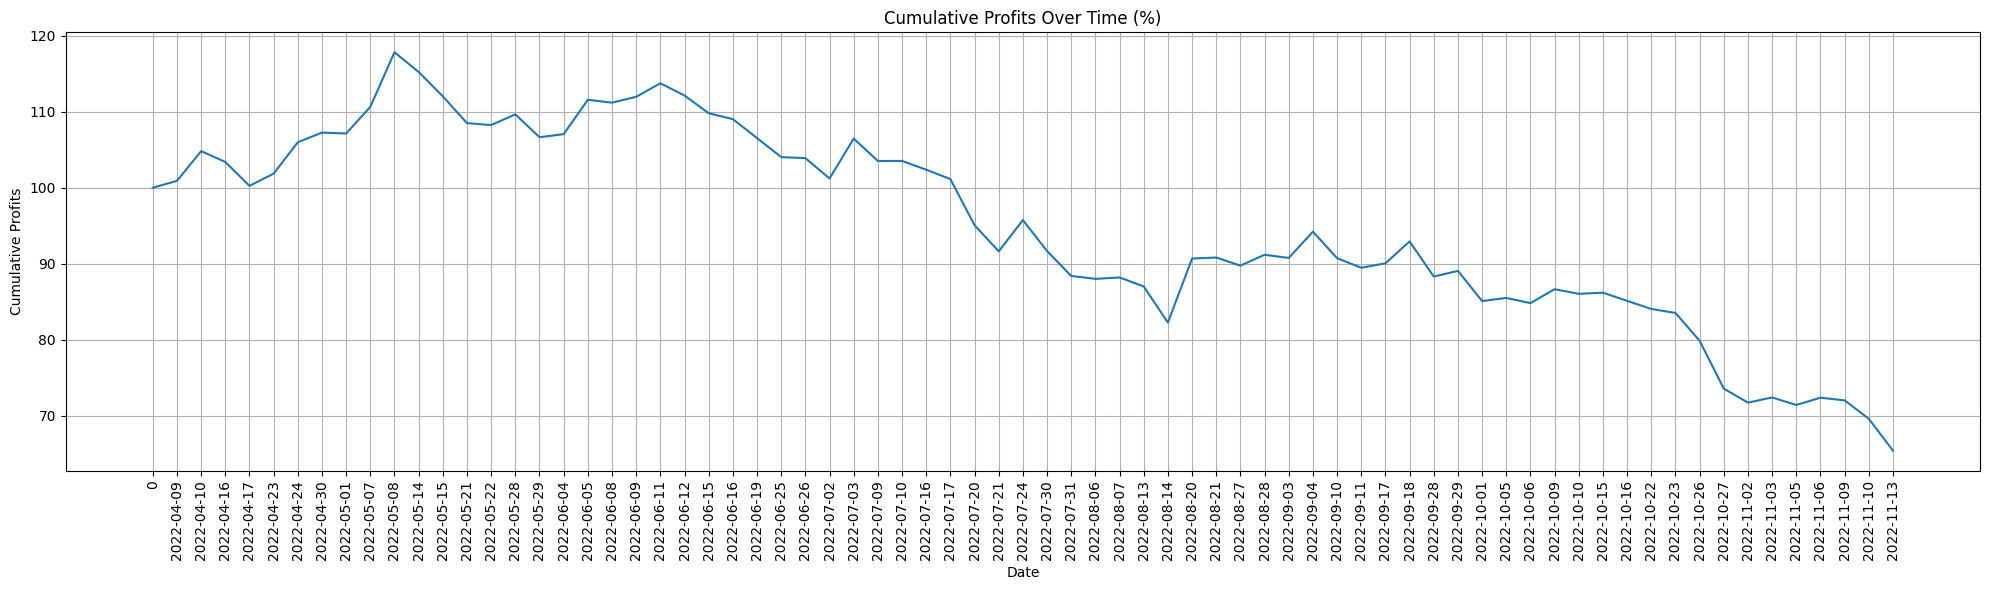

In [4]:
import matplotlib.pyplot as plt

df = df_plot
""" Create a line plot."""
plt.figure(figsize=(20, 6))
plt.plot(df.date, df.stake, linestyle='-')
plt.title('Cumulative Profits Over Time (%)')
plt.xlabel('Date')
plt.ylabel('Cumulative Profits')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
#plt.savefig(f"{path}/plot.PNG")